In [6]:
import pandas as pd
import numpy as np

from IPython.display import clear_output

from sklearn.linear_model import LinearRegression
import geopandas as gpd
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
# from spopt.region.skater import Skater
from sklearn.preprocessing import StandardScaler

import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap, MarkerCluster

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

from ipywidgets import interact, widgets

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# gdf = gpd.read_file(r"D:\CDR_study_areas\output\gdf_aggregate_new.geojson")
# gdf = gpd.read_file("/content/gdf_aggregate_new.geojson")

In [15]:
gdf.drop(columns=['LZNAME', 'AEZclassna', 'Shape_Leng', 'Shape_Area'], inplace=True, errors='ignore')
# add lat and lon columns
gdf

,fid,COMMUNE,REGION,LZCODE,DEM,aug_22,nov_dec_24,oct_24,recur,AEZclass,...,Wet_VHI_M_2024_scaled,Dry_precip_log_2021_scaled,Dry_precip_log_2022_scaled,Dry_precip_log_2023_scaled,Dry_precip_log_2024_scaled,Wet_precip_log_2021_scaled,Wet_precip_log_2022_scaled,Wet_precip_log_2023_scaled,Wet_precip_log_2024_scaled,geometry
0,1.0,TAMBACOUNDA,TAMBACOUNDA,14,50,0.000000,0.000000e+00,0.000000,0,2,...,0.000000,0.464361,0.241222,0.036039,0.824793,0.940413,0.839592,0.896804,0.894627,"POLYGON ((-13.64812 13.78878, -13.64785 13.788..."
1,2.0,BAKEL,TAMBACOUNDA,03,28,0.000000,0.000000e+00,0.056679,1,50,...,0.578389,0.000000,0.041646,0.002626,0.000000,0.828406,0.853439,0.852330,0.855038,"POLYGON ((-12.45054 14.90702, -12.45081 14.906..."
2,3.0,BARGNY,DAKAR,01,5,0.003143,0.000000e+00,0.000000,1,2,...,0.301013,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"POLYGON ((-17.22586 14.71718, -17.22541 14.716..."
3,4.0,KANEL,MATAM,04,15,0.122824,7.662653e-02,0.121164,3,53,...,0.409551,0.000000,0.093010,0.091926,0.000000,0.728483,0.826513,0.769551,0.808970,"POLYGON ((-13.16923 15.4729, -13.17825 15.4724..."
4,5.0,KEDOUGOU,KEDOUGOU,15,115,0.000000,0.000000e+00,0.000758,1,50,...,0.771346,0.000000,0.000000,0.173151,0.085010,0.911627,0.893802,0.926861,0.916508,"POLYGON ((-12.14358 12.59416, -12.13871 12.591..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,549.0,TESSEKERE FORAGE,LOUGA,06,48,0.000000,0.000000e+00,0.000000,0,53,...,0.578389,0.012053,1.000000,0.628813,0.957095,0.664050,0.801309,0.827227,0.745420,"POLYGON ((-15.35661 16.03678, -15.34983 16.029..."
549,550.0,YANG YANG,LOUGA,06,49,0.000000,8.521420e-07,0.000000,1,53,...,0.638688,0.000000,1.000000,0.747062,1.000000,0.678290,0.824673,0.843535,0.736883,"POLYGON ((-15.29089 15.73521, -15.29033 15.732..."
550,551.0,YEUMBEUL NORD,DAKAR,00,9,0.000000,0.000000e+00,0.000000,0,56,...,0.409551,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"POLYGON ((-17.35422 14.80083, -17.35386 14.800..."
551,552.0,YEUMBEUL SUD,DAKAR,00,11,0.000000,0.000000e+00,0.000000,0,56,...,0.530150,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"POLYGON ((-17.36756 14.77359, -17.36749 14.773..."


In [16]:
gdf.columns

Index(['fid', 'COMMUNE', 'REGION', 'LZCODE', 'DEM', 'aug_22', 'nov_dec_24',
       'oct_24', 'recur', 'AEZclass', 'AEZclassname', 'popsum2021',
       'popmean2021', 'popsum2022', 'popmean2022', 'popsum2023', 'popmean2023',
       'popsum2024', 'popmean2024', 'Rainfed_percentage_scaled',
       'Wetland_percentage_scaled', 'Bare_percentage_scaled',
       'Impervious_percentage_scaled', 'Water_percentage_scaled',
       'Irrigated_percentage_scaled', 'Shrubland_percentage_scaled',
       'Forest_percentage_scaled', 'Grassland_percentage_scaled',
       'Dry_LST_2021_scaled', 'Dry_LST_2022_scaled', 'Dry_LST_2023_scaled',
       'Dry_LST_2024_scaled', 'Wet_LST_2021_scaled', 'Wet_LST_2022_scaled',
       'Wet_LST_2023_scaled', 'Wet_LST_2024_scaled', 'Dry_NDVI_2021_scaled',
       'Dry_NDVI_2022_scaled', 'Dry_NDVI_2023_scaled', 'Dry_NDVI_2024_scaled',
       'Wet_NDVI_2021_scaled', 'Wet_NDVI_2022_scaled', 'Wet_NDVI_2023_scaled',
       'Wet_NDVI_2024_scaled', 'Dry_VHI_M_2021_scaled',
     

In [ ]:
# export it as a CSV file
# gdf.to_csv(r"D:\CDR_study_areas\output\gdf_final.csv", index=False)

In [17]:
# get centroid of each geometry and add as lat and lon columns
gdf['lat'] = gdf.geometry.centroid.y
gdf['lon'] = gdf.geometry.centroid.x
gdf

,fid,COMMUNE,REGION,LZCODE,DEM,aug_22,nov_dec_24,oct_24,recur,AEZclass,...,Dry_precip_log_2022_scaled,Dry_precip_log_2023_scaled,Dry_precip_log_2024_scaled,Wet_precip_log_2021_scaled,Wet_precip_log_2022_scaled,Wet_precip_log_2023_scaled,Wet_precip_log_2024_scaled,geometry,lat,lon
0,1.0,TAMBACOUNDA,TAMBACOUNDA,14,50,0.000000,0.000000e+00,0.000000,0,2,...,0.241222,0.036039,0.824793,0.940413,0.839592,0.896804,0.894627,"POLYGON ((-13.64812 13.78878, -13.64785 13.788...",13.765853,-13.670437
1,2.0,BAKEL,TAMBACOUNDA,03,28,0.000000,0.000000e+00,0.056679,1,50,...,0.041646,0.002626,0.000000,0.828406,0.853439,0.852330,0.855038,"POLYGON ((-12.45054 14.90702, -12.45081 14.906...",14.899442,-12.470759
2,3.0,BARGNY,DAKAR,01,5,0.003143,0.000000e+00,0.000000,1,2,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"POLYGON ((-17.22586 14.71718, -17.22541 14.716...",14.702229,-17.229872
3,4.0,KANEL,MATAM,04,15,0.122824,7.662653e-02,0.121164,3,53,...,0.093010,0.091926,0.000000,0.728483,0.826513,0.769551,0.808970,"POLYGON ((-13.16923 15.4729, -13.17825 15.4724...",15.493694,-13.176750
4,5.0,KEDOUGOU,KEDOUGOU,15,115,0.000000,0.000000e+00,0.000758,1,50,...,0.000000,0.173151,0.085010,0.911627,0.893802,0.926861,0.916508,"POLYGON ((-12.14358 12.59416, -12.13871 12.591...",12.569369,-12.174178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,549.0,TESSEKERE FORAGE,LOUGA,06,48,0.000000,0.000000e+00,0.000000,0,53,...,1.000000,0.628813,0.957095,0.664050,0.801309,0.827227,0.745420,"POLYGON ((-15.35661 16.03678, -15.34983 16.029...",15.854826,-15.163856
549,550.0,YANG YANG,LOUGA,06,49,0.000000,8.521420e-07,0.000000,1,53,...,1.000000,0.747062,1.000000,0.678290,0.824673,0.843535,0.736883,"POLYGON ((-15.29089 15.73521, -15.29033 15.732...",15.624930,-15.278292
550,551.0,YEUMBEUL NORD,DAKAR,00,9,0.000000,0.000000e+00,0.000000,0,56,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"POLYGON ((-17.35422 14.80083, -17.35386 14.800...",14.782345,-17.351247
551,552.0,YEUMBEUL SUD,DAKAR,00,11,0.000000,0.000000e+00,0.000000,0,56,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"POLYGON ((-17.36756 14.77359, -17.36749 14.773...",14.767963,-17.360413


In [18]:
clustering_vars = ['Rainfed_percentage_scaled',
       'Wetland_percentage_scaled', 'Bare_percentage_scaled',
       'Impervious_percentage_scaled', 'Water_percentage_scaled',
       'Irrigated_percentage_scaled', 'Shrubland_percentage_scaled',
       'Forest_percentage_scaled', 'Grassland_percentage_scaled',
       'Dry_LST_2024_scaled', 'Wet_LST_2024_scaled', 'Dry_NDVI_2024_scaled',
       'Wet_NDVI_2024_scaled', 'Dry_VHI_M_2024_scaled', 'Wet_VHI_M_2024_scaled',
       'Dry_precip_log_2024_scaled',
       'Wet_precip_log_2024_scaled']

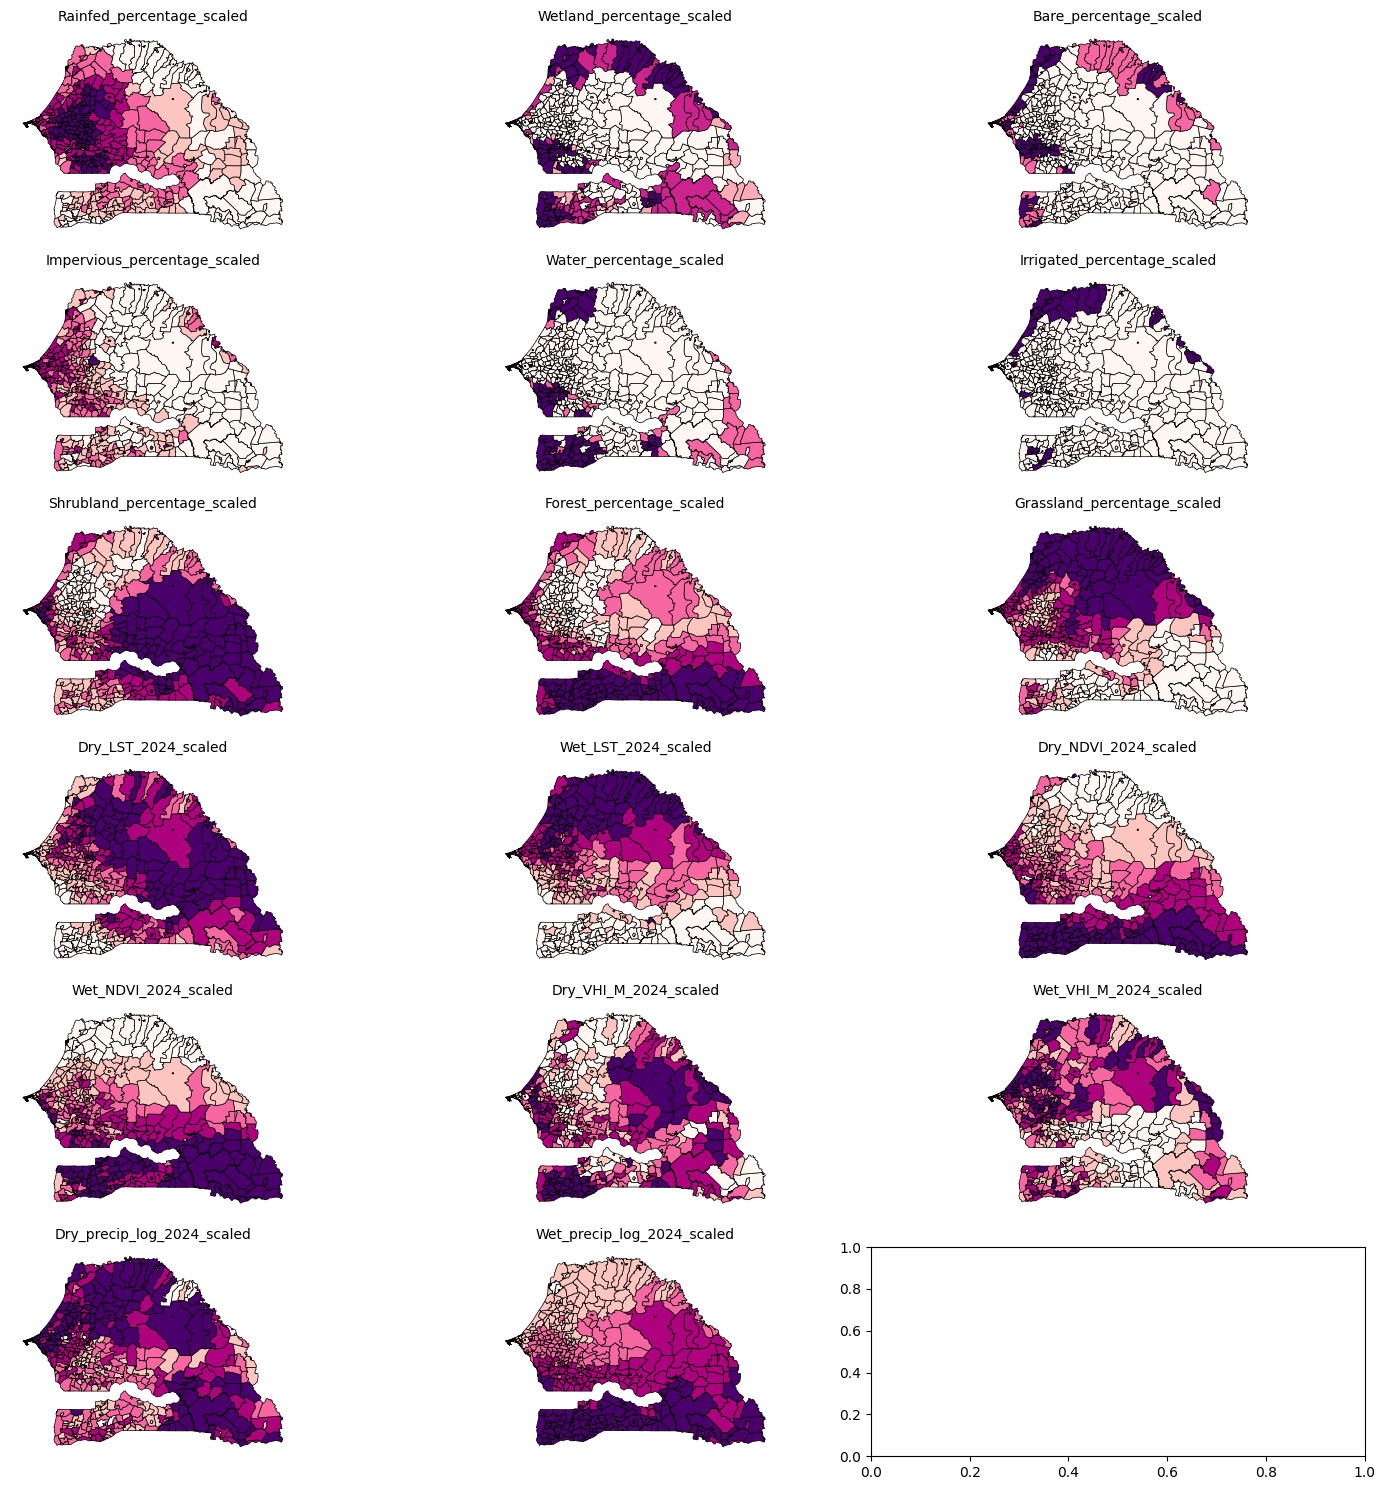

In [19]:
f, axs = plt.subplots(6,3 , figsize=(15, 15))

axs = axs.flatten()

for i , col in enumerate(clustering_vars):
    ax = axs[i]
    gdf.plot(column=col, ax=ax,
             scheme='quantiles', cmap='RdPu',
             legend=False, edgecolor='black', linewidth=0.5)
    ax.set_title(col, fontsize=10)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [20]:
w = Queen.from_dataframe(gdf)

np.random.seed(42)

mi_results = [Moran(gdf[col], w) for col in clustering_vars]

mi_results = [
    (col, result.I, result.p_sim)
    for col, result in zip(clustering_vars, mi_results)
]

mi_df = pd.DataFrame(mi_results, columns=['Variable', 'Moran_I', 'p_value']).set_index('Variable')
mi_df

('WARNING: ', 93, ' is an island (no neighbors)')


,Moran_I,p_value
Variable,,
Rainfed_percentage_scaled,0.910954,0.001
Wetland_percentage_scaled,0.597145,0.001
Bare_percentage_scaled,0.500380,0.001
Impervious_percentage_scaled,0.807871,0.001
Water_percentage_scaled,0.655478,0.001
Irrigated_percentage_scaled,0.768707,0.001
Shrubland_percentage_scaled,0.891868,0.001
Forest_percentage_scaled,0.953355,0.001
Grassland_percentage_scaled,0.872460,0.001


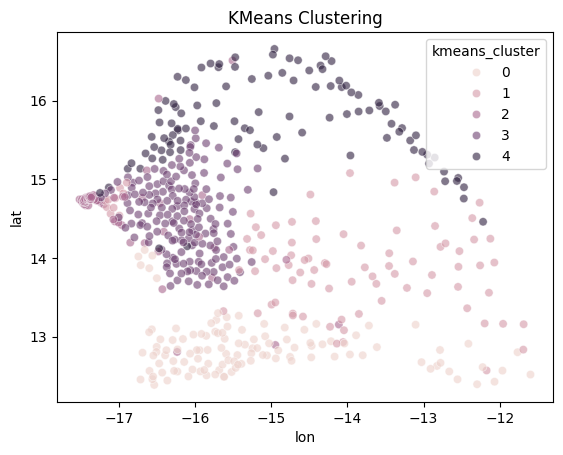

In [21]:
Kmeans = KMeans(n_clusters=5, random_state=42)
kmeans = Kmeans.fit(gdf[clustering_vars])
gdf['kmeans_cluster'] = kmeans.labels_

sns.scatterplot(data=gdf, x='lon', y='lat', hue='kmeans_cluster', alpha=0.6)
plt.title('KMeans Clustering')
plt.show()

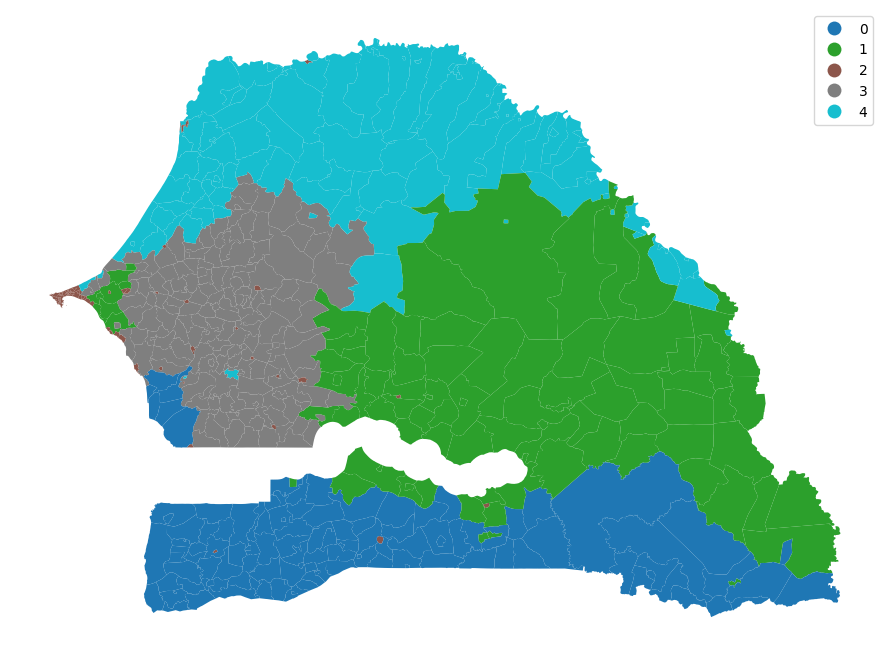

In [22]:
# plot the gdf with kmeans clusters
f, ax = plt.subplots(1, figsize=(9, 9))
gdf.plot(column='kmeans_cluster', categorical=True, legend=True, linewidth=0, ax=ax)
ax.set_axis_off()
plt.tight_layout()
plt.show(

)

In [23]:
print("k_means_size:", gdf.groupby('kmeans_cluster').size())

k_means_size: kmeans_cluster
0    118
1     89
2     74
3    168
4    104
dtype: int64


In [24]:
print(gdf.groupby('kmeans_cluster')[clustering_vars].mean().T.round(2))

kmeans_cluster                   0     1     2     3     4
Rainfed_percentage_scaled     0.01  0.07  0.08  0.77  0.08
Wetland_percentage_scaled     0.16  0.01  0.03  0.02  0.12
Bare_percentage_scaled        0.03  0.01  0.15  0.06  0.11
Impervious_percentage_scaled  0.02  0.02  0.70  0.03  0.06
Water_percentage_scaled       0.27  0.00  0.02  0.02  0.03
Irrigated_percentage_scaled   0.02  0.00  0.05  0.00  0.17
Shrubland_percentage_scaled   0.13  0.70  0.08  0.06  0.07
Forest_percentage_scaled      0.73  0.11  0.03  0.02  0.01
Grassland_percentage_scaled   0.06  0.16  0.14  0.17  0.78
Dry_LST_2024_scaled           0.53  0.85  0.33  0.77  0.77
Wet_LST_2024_scaled           0.10  0.40  0.53  0.59  0.81
Dry_NDVI_2024_scaled          0.65  0.30  0.15  0.26  0.18
Wet_NDVI_2024_scaled          0.80  0.73  0.24  0.61  0.25
Dry_VHI_M_2024_scaled         0.61  0.47  0.32  0.42  0.44
Wet_VHI_M_2024_scaled         0.53  0.45  0.40  0.67  0.69
Dry_precip_log_2024_scaled    0.24  0.32  0.06  0.32  0.

## Hierarchical Clustering

In [25]:
np.random.seed(42)

model = AgglomerativeClustering(n_clusters=5, linkage='ward')
model.fit(gdf[clustering_vars])
gdf['agglo_cluster'] = model.labels_

In [26]:
print("agglo_size:", gdf.groupby('agglo_cluster').size())

agglo_size: agglo_cluster
0    110
1    121
2    176
3     91
4     55
dtype: int64


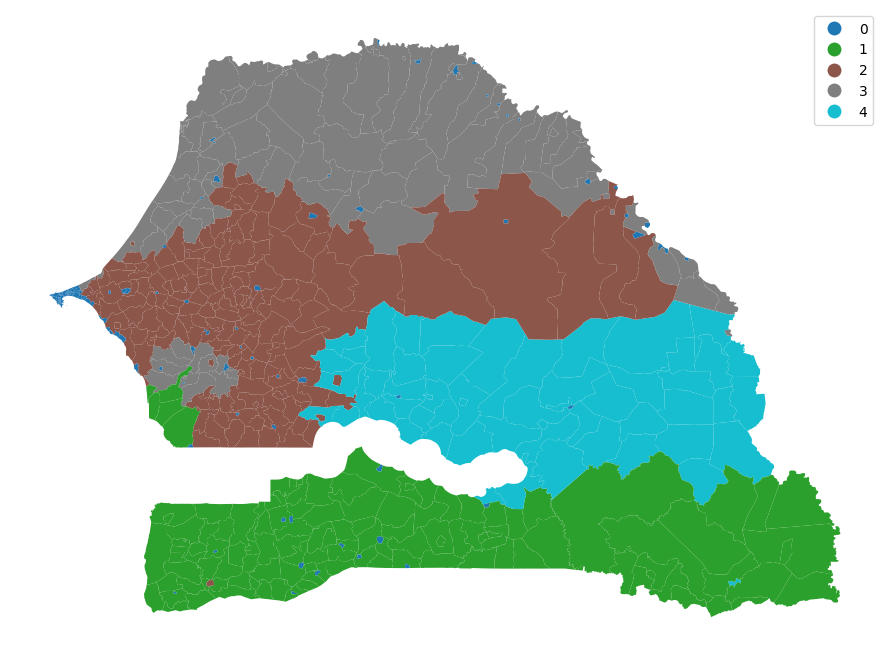

In [27]:
# plot the gdf with kmeans clusters
f, ax = plt.subplots(1, figsize=(9, 9))
gdf.plot(column='agglo_cluster', categorical=True, legend=True, linewidth=0, ax=ax)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Hierarchical Clustering with Spatial Constraints

In [28]:
np.random.seed(42)

model = AgglomerativeClustering(n_clusters=5, linkage='ward', connectivity=w.sparse)
model.fit(gdf[clustering_vars])
gdf['agglo_cluster_w'] = model.labels_

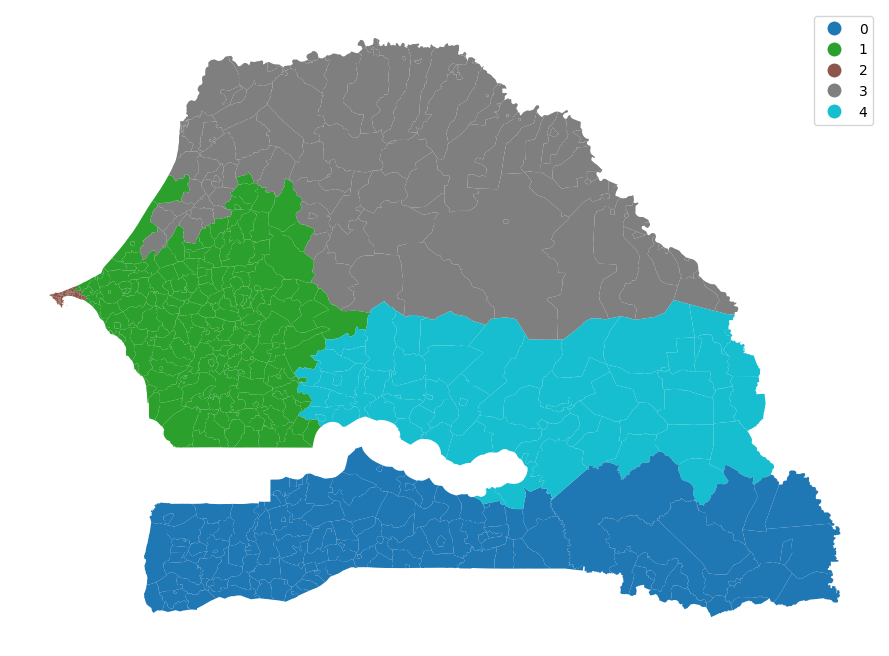

In [29]:
# plot the gdf with kmeans clusters
f, ax = plt.subplots(1, figsize=(9, 9))
gdf.plot(column='agglo_cluster_w', categorical=True, legend=True, linewidth=0, ax=ax)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [30]:
# flood exposure score from available flood columns
flood_cols = ['aug_22', 'nov_dec_24', 'oct_24']
available_flood_cols = [col for col in flood_cols if col in gdf.columns]

if available_flood_cols:
    gdf['flood_exposure'] = gdf[available_flood_cols].mean(axis=1)
else:
    print("No flood columns found!")

In [31]:

# params
sample_size = 56
pop_col = 'popsum2024'

pop_candidates = [col for col in gdf.columns if 'pop' in col.lower()]
if pop_candidates:
    print("Available population columns:", pop_candidates)

    if 'popsum2024' in gdf.columns:
        pop_col = 'popsum2024'
    elif 'pop_sum_2024' in gdf.columns:
        pop_col = 'pop_sum_2024'
    else:
        pop_col = pop_candidates[0]
    print(f"Using population column: {pop_col}")
else:
    print("No population column found!")


flood_threshold = gdf['flood_exposure'].quantile(0.5)  # can change this
print(f"Flood exposure threshold (median): {flood_threshold:.3f}")

gdf['status'] = np.where(gdf['flood_exposure'] > flood_threshold, 'affected', 'control')

print(f"\nOverall distribution:")
print(f"Total communes: {len(gdf)}")
print(f"Affected: {(gdf['status'] == 'affected').sum()}")
print(f"Control: {(gdf['status'] == 'control').sum()}")

gdf['pop_quartile'] = pd.qcut(gdf[pop_col], q=4, labels=['Q1_Low', 'Q2_Med-Low', 'Q3_Med-High', 'Q4_High'], duplicates='drop')

print(f"\nDistribution by status and population quartile:")
crosstab = pd.crosstab(gdf['status'], gdf['pop_quartile'], margins=True)
print(crosstab)

target_affected = 28
target_control = 28

print(f"\nTarget sampling: {target_affected} affected + {target_control} control = {sample_size} total")

def stratified_sample_by_pop(data, n_samples, group_name):
    """Sample from data ensuring representation across population quartiles"""

    if len(data) <= n_samples:
        print(f"  {group_name}: Taking all {len(data)} communes (fewer than target)")
        return data

    quartile_dist = data['pop_quartile'].value_counts()
    print(f"  {group_name} quartile distribution: {dict(quartile_dist)}")

    quartile_props = quartile_dist / len(data)
    quartile_targets = (quartile_props * n_samples).round().astype(int)


    while quartile_targets.sum() != n_samples:
        if quartile_targets.sum() < n_samples:
            quartile_targets[quartile_targets.idxmax()] += 1
        else:
            quartile_targets[quartile_targets.idxmin()] -= 1

    print(f"  {group_name} quartile targets: {dict(quartile_targets)}")

    # Sample from each quartile
    sampled_parts = []
    for quartile in quartile_targets.index:
        if quartile_targets[quartile] > 0:
            quartile_data = data[data['pop_quartile'] == quartile]
            n_quartile_samples = quartile_targets[quartile]

            if len(quartile_data) <= n_quartile_samples:
                sampled_parts.append(quartile_data)
                print(f"    {quartile}: Taking all {len(quartile_data)} communes")
            else:
                sampled = quartile_data.sample(n=n_quartile_samples, random_state=42)
                sampled_parts.append(sampled)
                print(f"    {quartile}: Sampled {len(sampled)} from {len(quartile_data)} communes")

    return pd.concat(sampled_parts) if sampled_parts else data.sample(n=min(n_samples, len(data)), random_state=42)


affected_communes = gdf[gdf['status'] == 'affected'].copy()
control_communes = gdf[gdf['status'] == 'control'].copy()

print(f"\n{'='*60}")
print("SAMPLING AFFECTED COMMUNES")
print(f"{'='*60}")


sampled_affected = stratified_sample_by_pop(affected_communes, target_affected, "Affected")

print(f"\n{'='*60}")
print("SAMPLING CONTROL COMMUNES")
print(f"{'='*60}")

sampled_control = stratified_sample_by_pop(control_communes, target_control, "Control")


final_sample = pd.concat([sampled_affected, sampled_control]).reset_index(drop=True)

print(f"\n{'='*60}")
print("FINAL STRATIFIED SAMPLE RESULTS")
print(f"{'='*60}")

print(f"Total sample size: {len(final_sample)} communes")
print(f"Affected: {len(sampled_affected)} communes")
print(f"Control: {len(sampled_control)} communes")

# Verify population distribution in sample
print(f"\nPopulation quartile distribution in sample:")
sample_quartile_dist = pd.crosstab(final_sample['status'], final_sample['pop_quartile'], margins=True)
print(sample_quartile_dist)


print(f"\nPopulation statistics comparison:")
print(f"Original affected - Mean: {affected_communes[pop_col].mean():,.0f}, Median: {affected_communes[pop_col].median():,.0f}")
print(f"Sample affected - Mean: {sampled_affected[pop_col].mean():,.0f}, Median: {sampled_affected[pop_col].median():,.0f}")
print(f"Original control - Mean: {control_communes[pop_col].mean():,.0f}, Median: {control_communes[pop_col].median():,.0f}")
print(f"Sample control - Mean: {sampled_control[pop_col].mean():,.0f}, Median: {sampled_control[pop_col].median():,.0f}")

print(f"\nFlood exposure statistics:")
print(f"Original affected - Mean: {affected_communes['flood_exposure'].mean():.3f}, Median: {affected_communes['flood_exposure'].median():.3f}")
print(f"Sample affected - Mean: {sampled_affected['flood_exposure'].mean():.3f}, Median: {sampled_affected['flood_exposure'].median():.3f}")
print(f"Original control - Mean: {control_communes['flood_exposure'].mean():.3f}, Median: {control_communes['flood_exposure'].median():.3f}")
print(f"Sample control - Mean: {sampled_control['flood_exposure'].mean():.3f}, Median: {sampled_control['flood_exposure'].median():.3f}")


print(f"\nCluster representation in sample:")
for method, col in [('KMeans', 'kmeans_cluster'), ('Agglomerative', 'agglo_cluster'), ('Spatial_Agglomerative', 'agglo_cluster_w')]:
    print(f"\n{method}:")
    original_dist = gdf[col].value_counts(normalize=True).sort_index()
    sample_dist = final_sample[col].value_counts(normalize=True).sort_index()

    for cluster in sorted(gdf[col].unique()):
        orig_prop = original_dist.get(cluster, 0)
        samp_prop = sample_dist.get(cluster, 0)
        print(f"  Cluster {cluster}: Original {orig_prop:.3f}, Sample {samp_prop:.3f}, Diff {abs(orig_prop-samp_prop):.3f}")


print(f"\nFinal sample communes:")
display_cols = ['COMMUNE', 'REGION', 'status', 'pop_quartile', pop_col, 'flood_exposure',
                'kmeans_cluster', 'agglo_cluster', 'agglo_cluster_w']
available_display_cols = [col for col in display_cols if col in final_sample.columns]
print(final_sample[available_display_cols].sort_values(['status', 'pop_quartile']))

# Save sample if needed
# final_sample.to_csv(r"D:\CDR_study_areas\output\stratified_sample_56_communes.csv", index=False)
# print(f"\nSample saved to: D:\CDR_study_areas\output\stratified_sample_56_communes.csv")


Available population columns: ['popsum2021', 'popmean2021', 'popsum2022', 'popmean2022', 'popsum2023', 'popmean2023', 'popsum2024', 'popmean2024']
Using population column: popsum2024
Flood exposure threshold (median): 0.000

Overall distribution:
Total communes: 553
Affected: 208
Control: 345

Distribution by status and population quartile:
pop_quartile  Q1_Low  Q2_Med-Low  Q3_Med-High  Q4_High  All
status                                                     
affected          54          44           59       51  208
control           85          94           79       87  345
All              139         138          138      138  553

Target sampling: 28 affected + 28 control = 56 total

SAMPLING AFFECTED COMMUNES
  Affected quartile distribution: {'Q3_Med-High': np.int64(59), 'Q1_Low': np.int64(54), 'Q4_High': np.int64(51), 'Q2_Med-Low': np.int64(44)}
  Affected quartile targets: {'Q3_Med-High': np.int64(8), 'Q1_Low': np.int64(7), 'Q4_High': np.int64(7), 'Q2_Med-Low': np.int64(6)}
  

In [32]:

print(final_sample[['fid', 'COMMUNE', 'status', 'REGION']])
print(gdf)

      fid             COMMUNE    status       REGION
0     8.0               MATAM  affected        MATAM
1    45.0            BARKEDJI  affected        LOUGA
2   321.0             THIEPPE  affected        LOUGA
3   102.0         DAROU MINAM  affected     KAFFRINE
4   410.0        PIRE GOUREYE  affected        THIES
5   499.0            DIOUROUP  affected       FATICK
6   528.0    KEUR SAMBA GUEYE  affected       FATICK
7   246.0     KOUTHIABA WOLOF  affected  TAMBACOUNDA
8   117.0        DIANKE MAKHA  affected  TAMBACOUNDA
9   506.0       THIONCK ESSYL  affected   ZIGUINCHOR
10  505.0               MLOMP  affected   ZIGUINCHOR
11   82.0             MBOUMBA  affected  SAINT LOUIS
12  456.0   GALOYA TOUCOULEUR  affected  SAINT LOUIS
13   47.0             THIARNY  affected        LOUGA
14  109.0            MBADIANE  affected        LOUGA
15  500.0          TATTAGUINE  affected       FATICK
16  474.0           NGUENIENE  affected        THIES
17  525.0    NDIAYENE PEINDAO  affected  SAINT

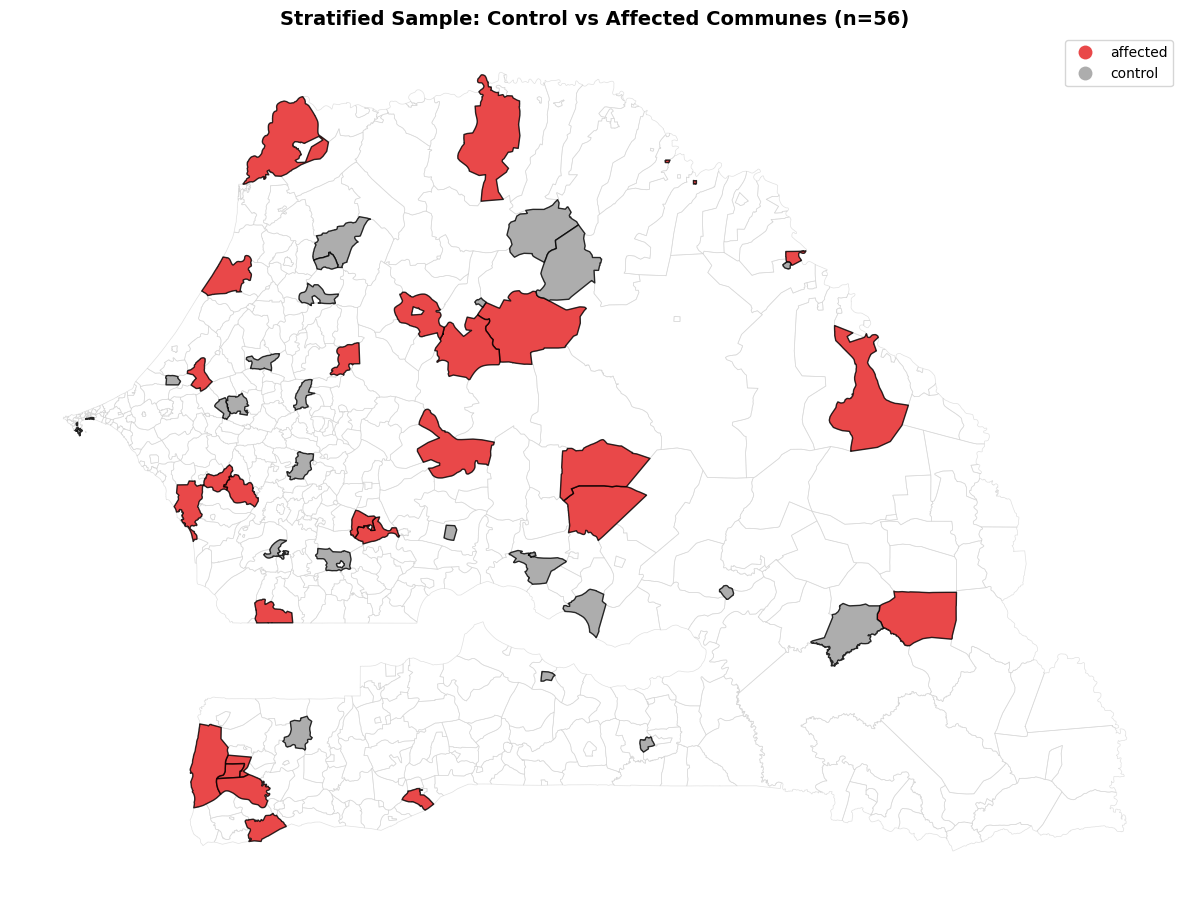

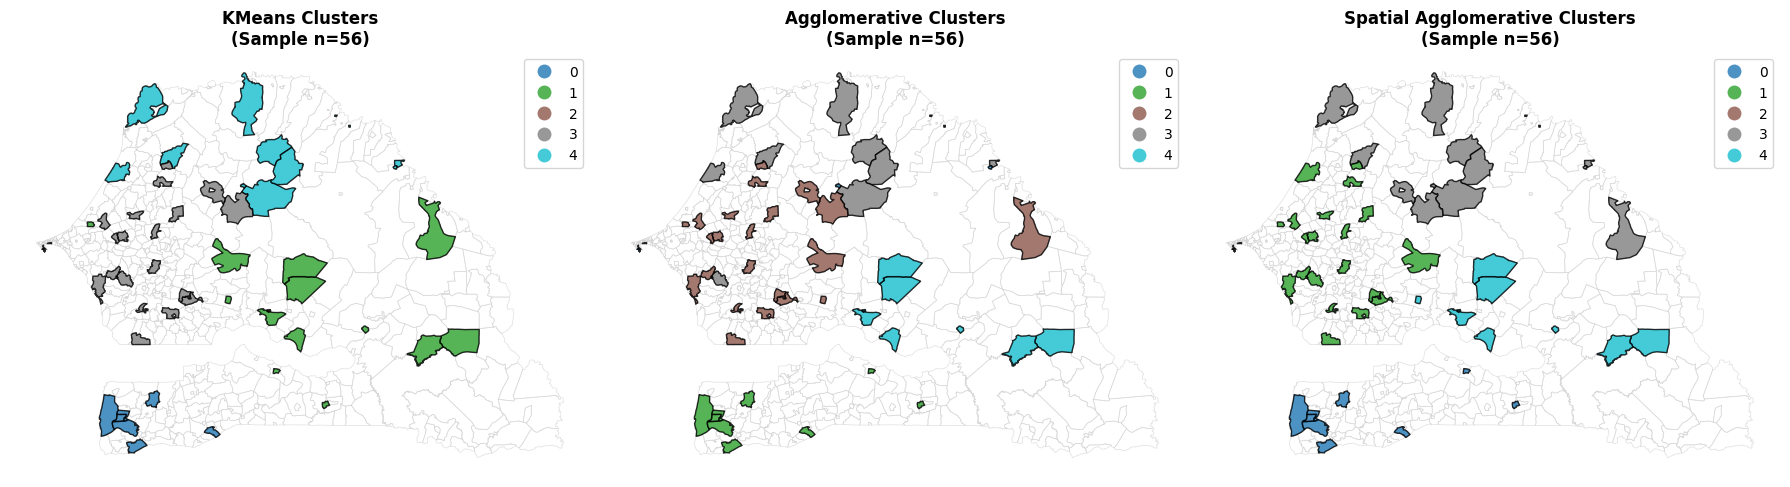

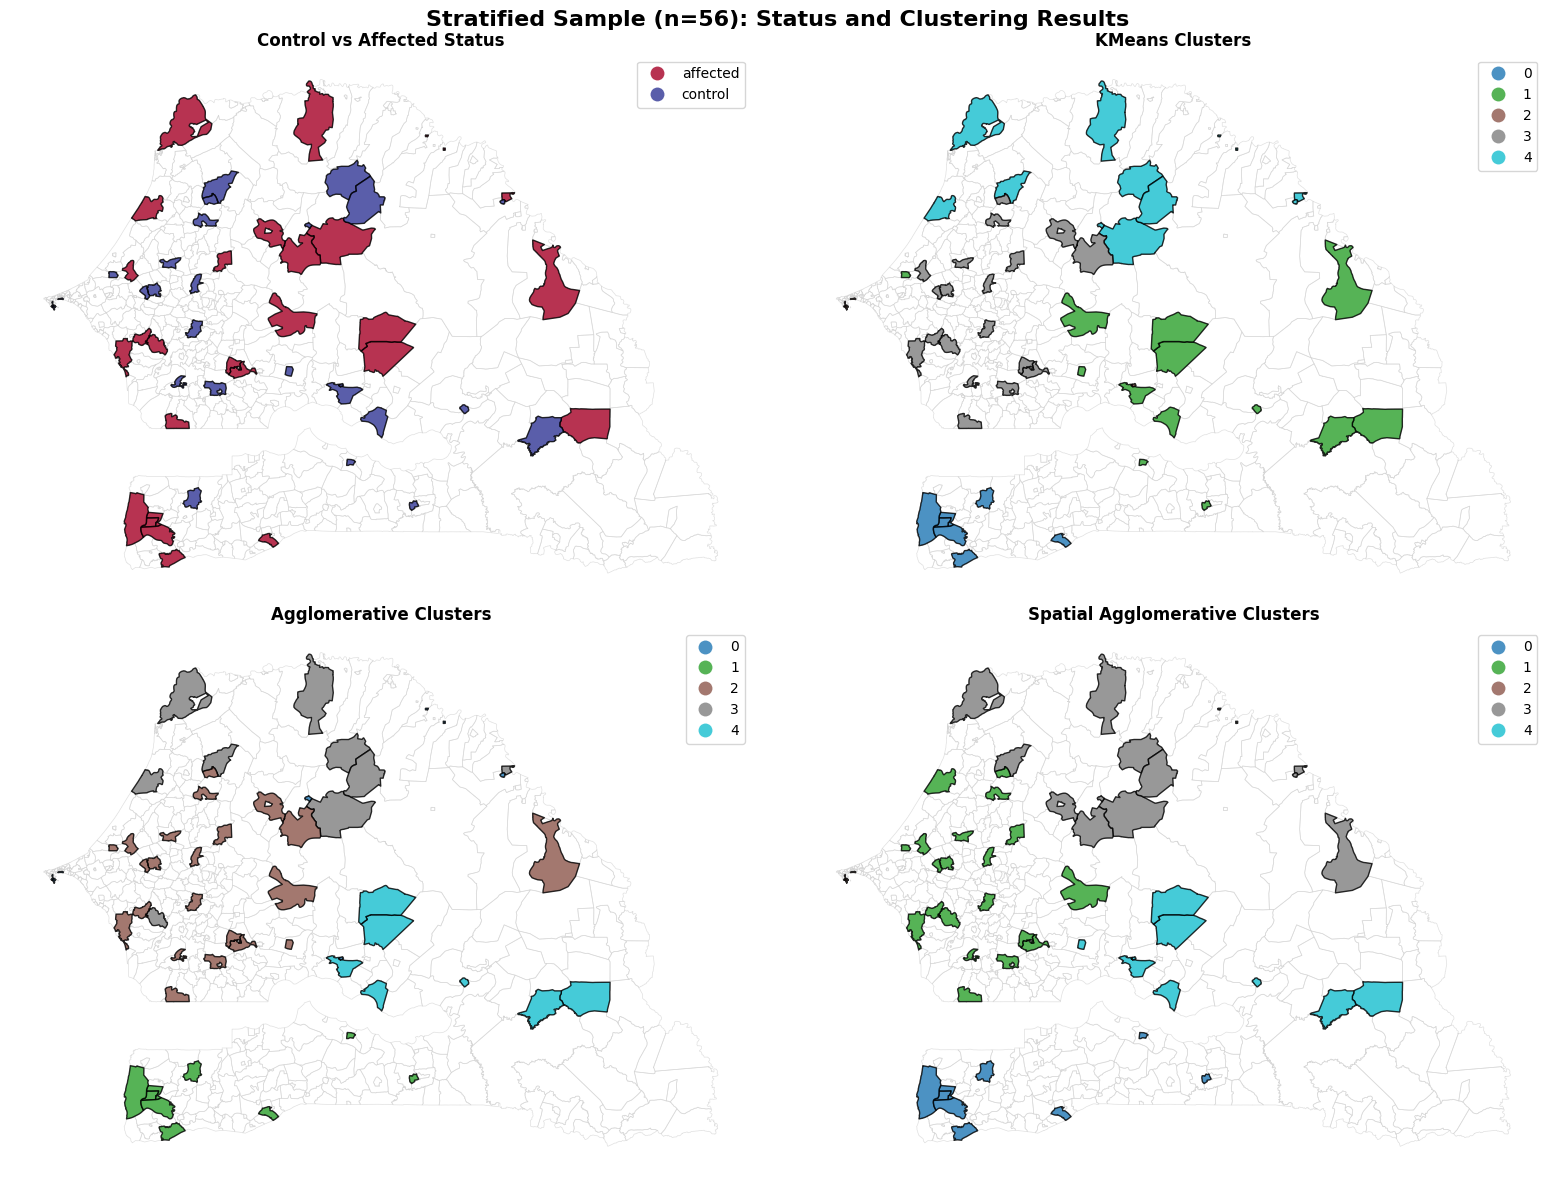

In [33]:

f, ax = plt.subplots(1, figsize=(12, 10))

gdf.plot(ax=ax, facecolor='none', edgecolor='lightgray', linewidth=0.5, alpha=0.7)

final_sample.plot(column='status', categorical=True, legend=True,
                 linewidth=1, ax=ax, edgecolor='black',
                 cmap='Set1', alpha=0.8)

ax.set_title('Stratified Sample: Control vs Affected Communes (n=56)', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cluster_methods = [
    ('KMeans', 'kmeans_cluster'),
    ('Agglomerative', 'agglo_cluster'),
    ('Spatial Agglomerative', 'agglo_cluster_w')
]

for i, (method_name, cluster_col) in enumerate(cluster_methods):
    ax = axes[i]


    gdf.plot(ax=ax, facecolor='none', edgecolor='lightgray', linewidth=0.5, alpha=0.7)


    final_sample.plot(column=cluster_col, categorical=True, legend=True,
                     linewidth=1, ax=ax, edgecolor='black',
                     cmap='tab10', alpha=0.8)

    ax.set_title(f'{method_name} Clusters\n(Sample n={len(final_sample)})',
                fontsize=12, fontweight='bold')
    ax.set_axis_off()

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(16, 12))


ax = axes[0, 0]
gdf.plot(ax=ax, facecolor='none', edgecolor='lightgray', linewidth=0.5, alpha=0.7)
final_sample.plot(column='status', categorical=True, legend=True,
                 linewidth=1, ax=ax, edgecolor='black',
                 cmap='RdYlBu', alpha=0.8)
ax.set_title('Control vs Affected Status', fontsize=12, fontweight='bold')
ax.set_axis_off()


for i, (method_name, cluster_col) in enumerate(cluster_methods):
    row = (i + 1) // 2
    col = (i + 1) % 2
    ax = axes[row, col]

    gdf.plot(ax=ax, facecolor='none', edgecolor='lightgray', linewidth=0.5, alpha=0.7)
    final_sample.plot(column=cluster_col, categorical=True, legend=True,
                     linewidth=1, ax=ax, edgecolor='black',
                     cmap='tab10', alpha=0.8)
    ax.set_title(f'{method_name} Clusters', fontsize=12, fontweight='bold')
    ax.set_axis_off()

plt.suptitle('Stratified Sample (n=56): Status and Clustering Results',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [34]:
gdf.drop(columns = ['geometrty'], inplace=True, errors='ignore')
gdf.to_csv("final_status.csv")


In [35]:
gdf

,fid,COMMUNE,REGION,LZCODE,DEM,aug_22,nov_dec_24,oct_24,recur,AEZclass,...,Wet_precip_log_2024_scaled,geometry,lat,lon,kmeans_cluster,agglo_cluster,agglo_cluster_w,flood_exposure,status,pop_quartile
0,1.0,TAMBACOUNDA,TAMBACOUNDA,14,50,0.000000,0.000000e+00,0.000000,0,2,...,0.894627,"POLYGON ((-13.64812 13.78878, -13.64785 13.788...",13.765853,-13.670437,1,4,4,0.000000e+00,control,Q4_High
1,2.0,BAKEL,TAMBACOUNDA,03,28,0.000000,0.000000e+00,0.056679,1,50,...,0.855038,"POLYGON ((-12.45054 14.90702, -12.45081 14.906...",14.899442,-12.470759,4,3,3,1.889308e-02,affected,Q2_Med-Low
2,3.0,BARGNY,DAKAR,01,5,0.003143,0.000000e+00,0.000000,1,2,...,0.000000,"POLYGON ((-17.22586 14.71718, -17.22541 14.716...",14.702229,-17.229872,2,0,1,1.047760e-03,affected,Q4_High
3,4.0,KANEL,MATAM,04,15,0.122824,7.662653e-02,0.121164,3,53,...,0.808970,"POLYGON ((-13.16923 15.4729, -13.17825 15.4724...",15.493694,-13.176750,4,3,3,1.068714e-01,affected,Q2_Med-Low
4,5.0,KEDOUGOU,KEDOUGOU,15,115,0.000000,0.000000e+00,0.000758,1,50,...,0.916508,"POLYGON ((-12.14358 12.59416, -12.13871 12.591...",12.569369,-12.174178,1,4,0,2.525480e-04,affected,Q4_High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,549.0,TESSEKERE FORAGE,LOUGA,06,48,0.000000,0.000000e+00,0.000000,0,53,...,0.745420,"POLYGON ((-15.35661 16.03678, -15.34983 16.029...",15.854826,-15.163856,4,3,3,0.000000e+00,control,Q2_Med-Low
549,550.0,YANG YANG,LOUGA,06,49,0.000000,8.521420e-07,0.000000,1,53,...,0.736883,"POLYGON ((-15.29089 15.73521, -15.29033 15.732...",15.624930,-15.278292,4,3,3,2.840473e-07,affected,Q1_Low
550,551.0,YEUMBEUL NORD,DAKAR,00,9,0.000000,0.000000e+00,0.000000,0,56,...,0.000000,"POLYGON ((-17.35422 14.80083, -17.35386 14.800...",14.782345,-17.351247,2,0,2,0.000000e+00,control,Q4_High
551,552.0,YEUMBEUL SUD,DAKAR,00,11,0.000000,0.000000e+00,0.000000,0,56,...,0.000000,"POLYGON ((-17.36756 14.77359, -17.36749 14.773...",14.767963,-17.360413,2,0,2,0.000000e+00,control,Q4_High
